/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_12512/2524314883.py:167: F

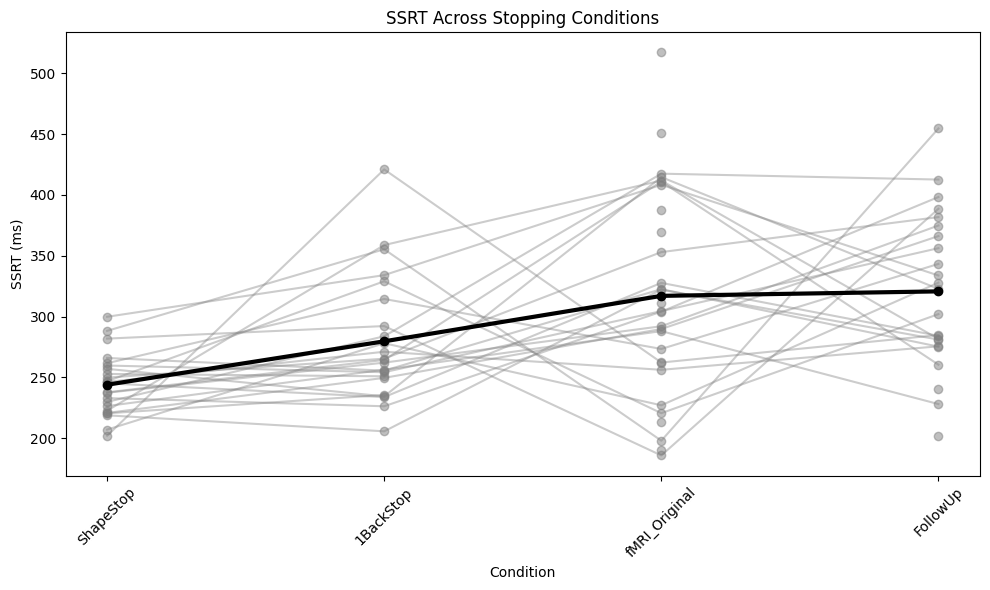

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install openpyxl

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install openpyxl

# ---------------------------
# 1. Define files and their column mappings
# ---------------------------
files_info = {
    "fMRI_Original": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/BeastfMRIN30.xlsx",
        "subject_col": "SubjID",
        "rt_col": "RT",
        "stop_acc_col": "StopAcc",
        "ssd_col": "SSD",
        "stop_go_col": "Stop1OrNoStop2",
        "go_code": 2,
        "stop_code": 1,
        "go_acc": "GoAcc",
        "stim_col": "Target1NonTarget2TempNonTarget3",
        "stim_map": {1: "Target", 2: "Non-target", 3: "Lure"}
    },
    "FollowUp": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/N23NonFMRIBeast.xlsx",
        "subject_col": "subject_id",
        "rt_col": "RT",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "SS_trial_type",
        "go_code": "go",
        "stop_code": "stop",
        "go_acc": "go_acc",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "1BackStop": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/1BackStoppingN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "stop_trial_type",
        "go_code": "go",
        "go_acc": "go_acc",
        "stop_code": "stop",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "NBackNoStop": {  # no stop trials
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/NBackNoStopN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": None,
        "ssd_col": None,
        "stop_go_col": None,
        "go_code": None,
        "stop_code": None,
        "go_acc": None,
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "ShapeStop": {
    "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/StopNoNBackN23.xlsx",
    "subject_col": "subject_ID",
    "rt_col": "rt",
    "stop_acc_col": "stop_acc",
    "ssd_col": "SS_delay",
    "stop_go_col": "SS_trial_type",
    "go_code": "go",     # <-- strings, not 0/1
    "stop_code": "stop",
    "go_acc": "go_acc",
    "shape_col": "go_stim",
    "shape_map": {"black_circle": "Circle", "black_triangle": "Triangle"}
}
}

# ---------------------------
# 2. SSRT computation function
# ---------------------------
def compute_ssrt(df, stop_go_col, stop_acc_col, ssd_col, rt_col, go_code, stop_code):
    df = df.copy()
    
    # skip if no stop trials (e.g., NBackNoStop)
    if stop_go_col is None or stop_acc_col is None or ssd_col is None:
        return np.nan
    
    # Map stop/go to 1 = stop, 2 = go
    df['stop_trial'] = df[stop_go_col].map({stop_code: 1, go_code: 2})
    go_trials = df[df['stop_trial'] == 2]
    stop_trials = df[df['stop_trial'] == 1]
    
    if len(go_trials) == 0 or len(stop_trials) == 0:
        return np.nan
    
    p_respond = 1 - stop_trials[stop_acc_col].mean()
    go_rts = np.sort(go_trials[rt_col].values)
    n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
    n_idx = max(n_idx, 0)
    nth_rt = go_rts[n_idx]
    mean_ssd = stop_trials[ssd_col].mean()
    
    return nth_rt - mean_ssd

# ---------------------------
# 3. Loop through files and compute SSRT
# ---------------------------
ssrt_list = []

for cond_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace
    
    # Robust subject column detection
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    if subject_col is None:
        raise ValueError(f"Subject column not found in {cond_name} dataset")
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    for subj in df['subject'].unique():
        subj_df = df[df['subject'] == subj]
        try:
            ssrt = compute_ssrt(
                subj_df,
                stop_go_col=info.get('stop_go_col'),
                stop_acc_col=info.get('stop_acc_col'),
                ssd_col=info.get('ssd_col'),
                rt_col=info['rt_col'],
                go_code=info.get('go_code'),
                stop_code=info.get('stop_code')
            )
            ssrt_list.append({"subject": subj, "Condition": cond_name, "SSRT": ssrt})
        except Exception as e:
            print(f"Skipping subject {subj} in {cond_name}: {e}")

ssrt_df = pd.DataFrame(ssrt_list)

# Filter extreme SSRTs
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 100) & (ssrt_df['SSRT'] <= 600)]

# ---------------------------
# 4. Plot SSRT across stopping conditions
# ---------------------------
plt.figure(figsize=(10,6))

# Correct order: ShapeStop, 1BackStop, fMRI_Original, FollowUp
condition_order = ["ShapeStop", "1BackStop", "fMRI_Original", "FollowUp"]

# Apply categorical ordering
ssrt_df['Condition'] = pd.Categorical(ssrt_df['Condition'], categories=condition_order, ordered=True)

# Spaghetti plot (each subject)
for sub in ssrt_df['subject'].unique():
    sub_df = ssrt_df[ssrt_df['subject'] == sub].set_index('Condition').reindex(condition_order)
    plt.plot(condition_order, sub_df['SSRT'], color='gray', alpha=0.4)

# Mean line
mean_df = ssrt_df.groupby('Condition')['SSRT'].mean().reindex(condition_order)
plt.plot(condition_order, mean_df, color='black', linewidth=3, marker='o')

# Overlay individual points
for cond in condition_order:
    y_vals = ssrt_df[ssrt_df['Condition'] == cond]['SSRT']
    x_vals = [cond]*len(y_vals)
    plt.scatter(x_vals, y_vals, color='gray', alpha=0.5)

plt.xlabel("Condition")
plt.ylabel("SSRT (ms)")
plt.title("SSRT Across Stopping Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


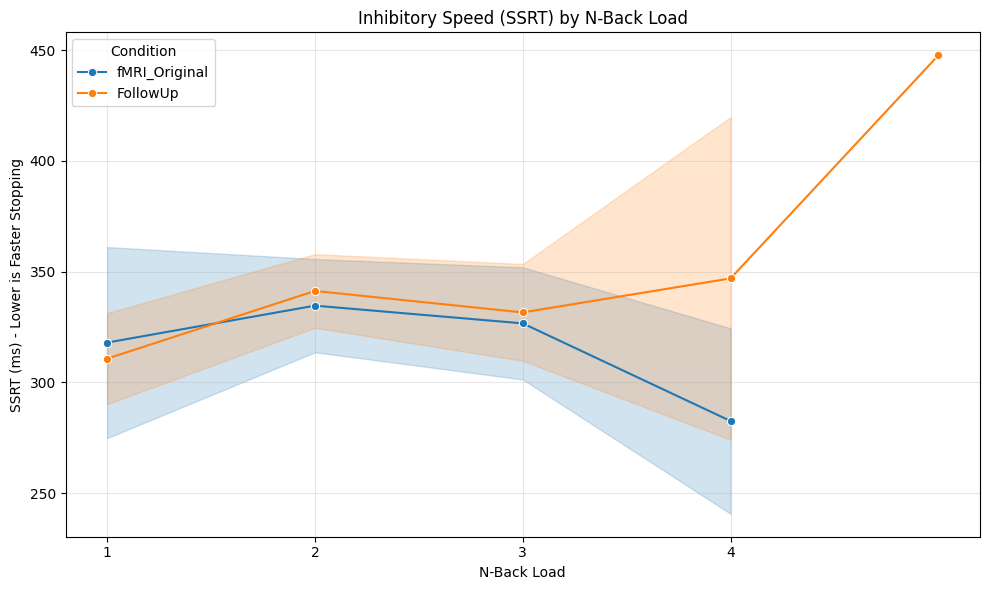

Mean SSRT per Load:
Load
1.0    315.15
2.0    337.55
3.0    328.74
4.0    321.21
5.0    447.75
Name: SSRT, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------
# SSRT ANALYSIS BY LOAD
# ---------------------------
ssrt_results = []
target_tasks = ["fMRI_Original", "FollowUp"]

for task in target_tasks:
    if task not in files_info: continue
    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # 1. Standardize Columns (Consistent with Cell 1)
    subj_col = next((c for c in df.columns if 'subj' in c.lower()), 'subject')
    acc_col = next((c for c in df.columns if 'stop' in c.lower() and 'acc' in c.lower()), None)
    load_col = next((c for c in df.columns if c.lower() == 'load'), 'Load')
    rt_col = info['rt_col']
    ssd_col = info.get('ssd_col')
    
    df.rename(columns={subj_col: 'subject', load_col: 'Load'}, inplace=True)

    # 2. Compute SSRT for each Subject at each Load level
    for (subj, load), subj_load_df in df.groupby(['subject', 'Load']):
        
        # Split into Go and Stop trials
        if 'NoStop1StopSuccess2StopFail3' in df.columns:
            go_trials = subj_load_df[subj_load_df['NoStop1StopSuccess2StopFail3'] == 1]
            stop_trials = subj_load_df[subj_load_df['NoStop1StopSuccess2StopFail3'].isin([2, 3])]
        else:
            go_trials = subj_load_df[subj_load_df['stop_trial_type'] == 'go']
            stop_trials = subj_load_df[subj_load_df['stop_trial_type'] != 'go']

        # Check for sufficient data (need both trial types to compute SSRT)
        if len(go_trials) >= 5 and len(stop_trials) >= 5:
            # Integration Method Calculation
            p_respond = 1 - stop_trials[acc_col].mean()
            go_rts = np.sort(go_trials[rt_col].dropna().values)
            
            # Find the RT corresponding to the probability of responding
            n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
            n_idx = max(0, min(n_idx, len(go_rts) - 1))
            
            ssrt = go_rts[n_idx] - stop_trials[ssd_col].mean()
            
            ssrt_results.append({
                "subject": subj, 
                "Condition": task, 
                "Load": load, 
                "SSRT": ssrt
            })

# 3. Clean and Plot
ssrt_df = pd.DataFrame(ssrt_results)
# Remove outliers (SSRTs outside 50-800ms are usually invalid)
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 50) & (ssrt_df['SSRT'] <= 800)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=ssrt_df, x='Load', y='SSRT', hue='Condition', marker='o', errorbar='se')

plt.title("Inhibitory Speed (SSRT) by N-Back Load")
plt.ylabel("SSRT (ms) - Lower is Faster Stopping")
plt.xlabel("N-Back Load")
plt.xticks([1, 2, 3, 4])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print averages for your slides
print("Mean SSRT per Load:")
print(ssrt_df.groupby('Load')['SSRT'].mean().round(2))

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


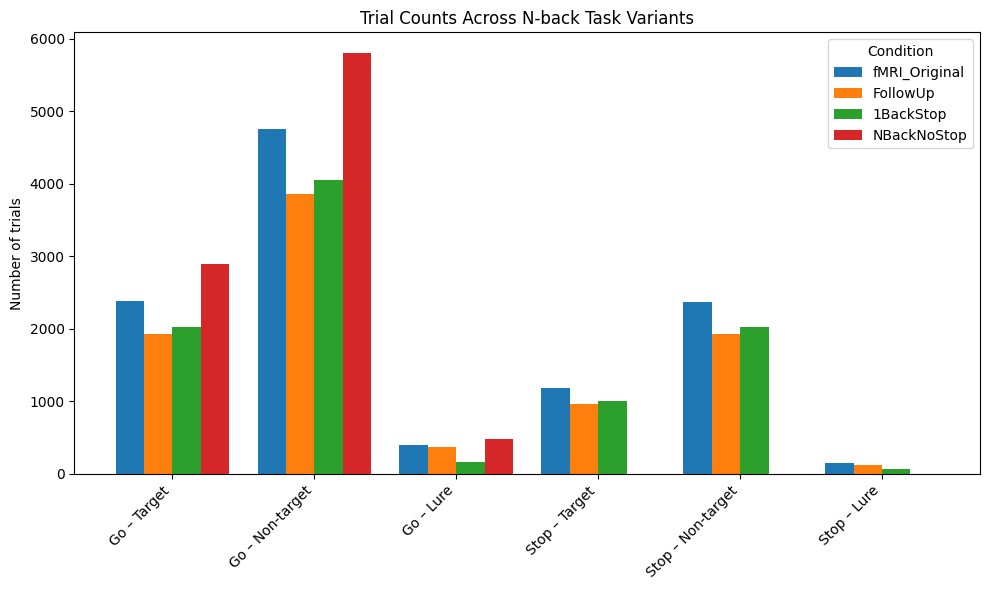

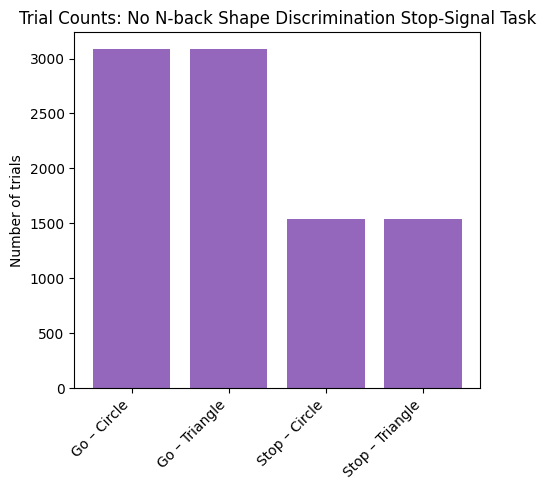

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


            Task   n_go  n_stop  stop_signal_proportion
0  fMRI_Original   7529    3711                0.330160
1       FollowUp   6163    3024                0.329161
2      1BackStop   6236    3102                0.332191
3    NBackNoStop  18749       0                0.000000
4      ShapeStop   6168    3084                0.333333


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


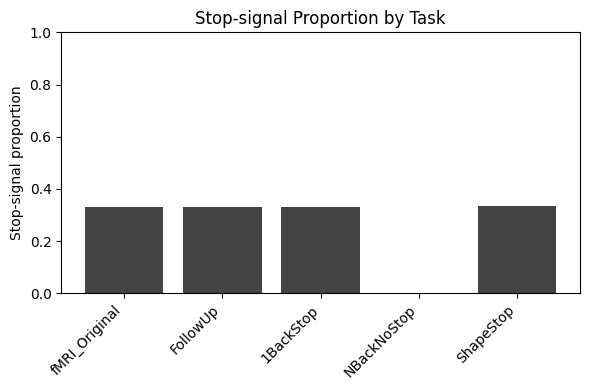

In [4]:
# ---------------------------
# Trial counts per condition x trial type
# ---------------------------

trial_counts_list = []

for task_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # ---- Stimulus label ----
    if task_name == "ShapeStop":
        df['stim_label'] = df[info['shape_col']].map(info['shape_map'])
    else:
        df['stim_label'] = df[info['stim_col']].map(info['stim_map'])

    # ---- Trial type ----
    if info['stop_go_col'] is not None:
        df['trial_type'] = df[info['stop_go_col']].map({info['stop_code']: 'Stop', info['go_code']: 'Go'})
        df['trial_label'] = df['trial_type'] + ' – ' + df['stim_label']
    else:
        df['trial_type'] = 'Go'
        df['trial_label'] = 'Go – ' + df['stim_label']

    # ---- Count trials per label ----
    counts = df.groupby('trial_label').size().reset_index(name='n_trials')
    counts['task'] = task_name
    trial_counts_list.append(counts)

# Combine all tasks
trial_counts = pd.concat(trial_counts_list, ignore_index=True)

# ---------------------------
# 1. Define trial types to include (for N-back)
# ---------------------------
trial_types_order = [
    "Go – Target", "Go – Non-target", "Go – Lure",
    "Stop – Target", "Stop – Non-target", "Stop – Lure"
]

# N-back tasks
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]

# ---------------------------
# 2. Pivot data for grouped bar plot
# ---------------------------
# Filter only N-back tasks
nback_counts = trial_counts[trial_counts["task"].isin(nback_tasks)]

# Pivot so that rows = trial_label, columns = task
pivot_df = nback_counts.pivot_table(
    index="trial_label",  # <-- corrected column name
    columns="task",
    values="n_trials",
    fill_value=0
)

# Reorder rows to desired trial type order
pivot_df = pivot_df.reindex(trial_types_order)

# ---------------------------
# 3. Plot grouped bar chart
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.2
x = np.arange(len(trial_types_order))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, task in enumerate(nback_tasks):
    ax.bar(x + i*bar_width, pivot_df[task], width=bar_width, label=task, color=colors[i])

ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(trial_types_order, rotation=45, ha="right")
ax.set_ylabel("Number of trials")
ax.set_title("Trial Counts Across N-back Task Variants")
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

# ---------------------------
# 4. Plot ShapeStop separately
# ---------------------------
shape_data = trial_counts[trial_counts["task"] == "ShapeStop"].copy()

plt.figure(figsize=(5,5))
plt.bar(shape_data["trial_label"], shape_data["n_trials"], color="#9467bd")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of trials")
plt.title("Trial Counts: No N-back Shape Discrimination Stop-Signal Task")
plt.tight_layout()
plt.show()








# ---------------------------
# 5. Stop signal proportion
# ---------------------------


stop_props = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Total trials
    total_trials = len(df)

    stop_col = info.get('stop_go_col')
    go_code = info.get('go_code')
    stop_code = info.get('stop_code')

    if stop_col is not None and go_code is not None and stop_code is not None:
        n_stop = (df[stop_col] == stop_code).sum()
        n_go = (df[stop_col] == go_code).sum()
        prop = n_stop / (n_stop + n_go)
    else:
        # If no stop/go column, assume all go trials
        n_stop = 0
        n_go = total_trials
        prop = 0

    stop_props.append({
        "Task": task,
        "n_go": n_go,
        "n_stop": n_stop,
        "stop_signal_proportion": prop
    })

stop_props_df = pd.DataFrame(stop_props)
print(stop_props_df)

plt.figure(figsize=(6,4))
plt.bar(stop_props_df["Task"], stop_props_df["stop_signal_proportion"], color="#444444")
plt.ylabel("Stop-signal proportion")
plt.title("Stop-signal Proportion by Task")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Prepare data for Go RTs
# ---------------------------
rt_list = []

for task, info in files_info.items():
    df = pd.read_excel(info["file"])
    
    # Clean subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    # Only include tasks with a stop/go column for Go RT selection
    if info.get("stop_go_col") is not None:
        # Filter Go trials and realistic RTs
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df = df[df[info["stop_go_col"]] == info["go_code"]]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])
    else:
        # For tasks with no stop/go (ShapeStop), include all RTs within range
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])

rt_df = pd.concat(rt_list, ignore_index=True)

# ---------------------------
# 2. Split into N-back vs ShapeStop
# ---------------------------
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]
shape_task = ["ShapeStop"]

rt_nback = rt_df[rt_df["Condition"].isin(nback_tasks)]
rt_shape = rt_df[rt_df["Condition"].isin(shape_task)]

# ---------------------------
# 3. Plot Go RT distributions
# ---------------------------
sns.set(style="whitegrid")

# N-back panel
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=rt_nback, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution Across N-back Conditions")
plt.show()

# ShapeStop panel
plt.figure(figsize=(6,5))
sns.kdeplot(
    data=rt_shape, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution: Shape Stop Task")
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acc_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace

    # Standardize subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)

    # Filter Go trials if stop/go column exists
    if info.get('stop_go_col') is not None:
        go_df = df[df[info['stop_go_col']] == info['go_code']].copy()
    else:
        go_df = df.copy()  # everything is Go

    # Handle Go accuracy
    go_acc_col = info.get('go_acc')
    if go_acc_col is not None and go_acc_col in df.columns:
        go_df['acc'] = go_df[go_acc_col]
    else:
        # If no go_acc, use adaptive_acc if available
        if 'adaptive_acc' in df.columns:
            go_df['acc'] = go_df['adaptive_acc']
        else:
            # If no accuracy data, set as NaN
            go_df['acc'] = pd.Series([None] * len(go_df))

    # Compute mean accuracy per subject
    mean_acc = go_df.groupby('subject')['acc'].mean().reset_index()
    mean_acc['Condition'] = task

    acc_list.append(mean_acc)

# Combine all tasks
acc_df = pd.concat(acc_list, ignore_index=True)

# Compute mean accuracy per condition, keeping NaN values if necessary
mean_acc_df = acc_df.groupby('Condition')['acc'].mean().reset_index()

# Optional: order conditions
condition_order = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop", "ShapeStop"]
mean_acc_df['Condition'] = pd.Categorical(mean_acc_df['Condition'], categories=condition_order, ordered=True)
mean_acc_df = mean_acc_df.sort_values('Condition')

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=mean_acc_df, x='Condition', y='acc', palette='pastel')
plt.ylim(0,1)
plt.ylabel('Mean Go Accuracy')
plt.title('Go Accuracy Across Task Variants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Gather SSDs from all tasks
# ---------------------------
ssd_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove any weird spaces

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only include trials that have SSD (skip tasks without stop signals)
    if info.get('ssd_col') is not None:
        df = df[df[info['stop_go_col']] == info['stop_code']]  # only Stop trials
        df['Condition'] = task
        df['SSD'] = df[info['ssd_col']]
        ssd_list.append(df[['subject', 'Condition', 'SSD']])

# Combine all tasks
ssd_df = pd.concat(ssd_list, ignore_index=True)

# ---------------------------
# 2. Plot SSD distributions
# ---------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Define colors to match conditions
conditions = ssd_df['Condition'].unique()
palette = sns.color_palette("tab10", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

# KDE per task
sns.kdeplot(
    data=ssd_df,
    x='SSD',
    hue='Condition',
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette=color_map
)

# Overlay mean SSD as vertical lines with matching colors
mean_ssd = ssd_df.groupby('Condition')['SSD'].mean()
for cond, mean_val in mean_ssd.items():
    plt.axvline(mean_val, linestyle='--', color=color_map[cond], label=f'{cond} mean')

plt.xlabel("SSD (ms)")
plt.ylabel("Density")
plt.title("SSD Distributions Across Stop-Signal Task Variants")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List to collect stop trial performance
stop_prob_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # clean column names

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only process tasks with stop trials
    if info.get('stop_go_col') is not None:
        # Identify stop trials
        stop_trials = df[df[info['stop_go_col']] == info['stop_code']].copy()
        
        # Probability of responding on stop trial: 1 = responded, 0 = successfully inhibited
        # If StopAcc column is 1 = successful stop, 0 = failed stop
        # Then responding = 1 - StopAcc
        stop_trials['responded'] = 1 - stop_trials[info['stop_acc_col']]

        # Compute mean per subject
        subj_mean = stop_trials.groupby('subject')['responded'].mean().reset_index()
        subj_mean['task'] = task
        stop_prob_list.append(subj_mean)

# Combine all tasks
stop_prob_df = pd.concat(stop_prob_list, ignore_index=True)

# ---------------------------
# Plot probability of responding given a stop signal
# ---------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=stop_prob_df, x='task', y='responded', palette="Set2")
sns.stripplot(data=stop_prob_df, x='task', y='responded', color='black', alpha=0.5, jitter=True)
plt.ylabel("Probability of Responding on Stop Trials")
plt.ylim(0,1)
plt.title("p(respond | stop) Across Tasks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

# ---------------------------
# 1. DATA LOADING & CLEANING
# ---------------------------
load_tasks = ["fMRI_Original", "FollowUp"]
all_go_trials = []

# Assuming files_info is defined with your file paths
for task in load_tasks:
    if task not in files_info: continue
    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # --- Standardize Subject ---
    subject_col = next((c for c in df.columns if 'subj' in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    # --- Standardize Accuracy (Handles 'GoAcc' and 'go_acc') ---
    acc_col = next((c for c in df.columns if 'go' in c.lower() and 'acc' in c.lower()), None)
    if acc_col:
        df.rename(columns={acc_col: 'acc'}, inplace=True)
    
    # --- Standardize Load ---
    load_col = next((c for c in df.columns if c.lower() == 'load'), None)
    if load_col:
        df['Load'] = df[load_col]

    # --- Standardize Outcome (Fixes the Regressor 9 ValueError) ---
    if 'stop_trial_type' in df.columns:
        df['n_back_outcome'] = df['stop_trial_type'].replace({'go': 'Go'})
    elif 'NoStop1StopSuccess2StopFail3' in df.columns:
        outcome_map = {1: 'Go', 2: 'Stop Success', 3: 'Stop Failure'}
        df['n_back_outcome'] = df['NoStop1StopSuccess2StopFail3'].map(outcome_map)
    else:
        df['n_back_outcome'] = 'Go'

    # --- Filter for Go Trials ---
    if 'NoStop1StopSuccess2StopFail3' in df.columns:
         go_df = df[df['NoStop1StopSuccess2StopFail3'] == 1].copy()
    elif info.get('stop_go_col'):
        go_df = df[df[info['stop_go_col']] == info['go_code']].copy()
    else:
        go_df = df.copy()

    go_df['Condition'] = task
    all_go_trials.append(go_df)

load_df = pd.concat(all_go_trials, ignore_index=True)

# ---------------------------------------------------------
# 2. COHORT IDENTIFICATION (The "Slide 11" 16-Subject Logic)
# ---------------------------------------------------------
subj_load_sets = load_df.groupby('subject')['Load'].unique().apply(set)

def get_balanced_cohort(all_data, required_loads):
    req_set = set(required_loads)
    mask = subj_load_sets.apply(lambda x: req_set.issubset(x))
    valid_subjects = subj_load_sets[mask].index
    return all_data[all_data['subject'].isin(valid_subjects) & all_data['Load'].isin(required_loads)]

# Creating the balanced subgroups
df_12   = get_balanced_cohort(load_df, [1, 2])
df_13   = get_balanced_cohort(load_df, [1, 2, 3])
df_1234 = get_balanced_cohort(load_df, [1, 2, 3, 4])

# ---------------------------
# 3. PLOTTING
# ---------------------------

# === PLOT 1: Go RT Distributions (Balanced Cohorts) ===
def plot_cohort_dist(data, loads, title):
    plt.figure(figsize=(10, 5))
    n_subj = data['subject'].nunique()
    # Using a distinct color palette for the different loads
    colors = sns.color_palette("husl", len(loads))
    
    for i, load in enumerate(loads):
        subset = data[data['Load'] == load]
        # Plot the KDE (Density)
        sns.kdeplot(data=subset, x='RT', fill=True, alpha=0.3, color=colors[i], label=f"Load {load}")
        # Add a vertical dashed line for the mean RT
        plt.axvline(subset['RT'].mean(), color=colors[i], linestyle='--', linewidth=2)
    
    plt.title(f"{title}\n(Analyzing only the {n_subj} subjects who completed all loads)")
    plt.xlabel("Go Reaction Time (ms)")
    plt.xlim(150, 1500)
    plt.legend(title="Difficulty")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Generate the two key comparisons for your slides
plot_cohort_dist(df_12, [1, 2], "Reaction Time Shift: Loads 1 vs 2")
plot_cohort_dist(df_123, [1, 2, 3], "Reaction Time Shift: Loads 1 through 3")
plot_cohort_dist(df_1234, [1, 2, 3, 4], "Reaction Time Shift: Loads 1 through 4")

# === PLOT 2: Mean Go Accuracy by Load (Population View) ===
plt.figure(figsize=(8,5))
sns.barplot(data=load_df, x='Load', y='acc', hue='Condition', palette='magma')
plt.ylabel("Mean Go Accuracy")
plt.ylim(0, 1.05)
plt.title("Mean Go Accuracy by N-back Load (All Subjects)")
plt.show()

# === PLOT 3: Regressor 9 - Encoding Interference ===
plt.figure(figsize=(10,6))
sns.pointplot(
    data=load_df, x='Load', y='acc', hue='n_back_outcome',
    hue_order=['Go', 'Stop Success', 'Stop Failure'],
    palette={'Go': 'gray', 'Stop Success': 'green', 'Stop Failure': 'red'},
    dodge=True, markers=['o', 's', 'X'], capsize=0.1
)
plt.title("Impact of Trial N-Back on Current Go Accuracy\n(Encoding Interference)")
plt.ylim(0.5, 1.05)
plt.show()

# Final Summary for your notes
print(f"Final Counts:")
print(f"- Total unique subjects: {load_df['subject'].nunique()}")
print(f"- Subjects in 1-4 Balanced Cohort: {df_1234['subject'].nunique()}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 1-back and 2-back loads
one_back_df = load_df[load_df['Load'] == 1]
two_back_df = load_df[load_df['Load'] == 2]

# Identify subjects who have data for both 1-back and 2-back
subjects_1_back = set(one_back_df['subject'].unique())
subjects_2_back = set(two_back_df['subject'].unique())
common_subjects = list(subjects_1_back.intersection(subjects_2_back))

# Extract accuracy data for these common subjects
one_back_acc = one_back_df[one_back_df['subject'].isin(common_subjects)].groupby('subject')['acc'].mean()
two_back_acc = two_back_df[two_back_df['subject'].isin(common_subjects)].groupby('subject')['acc'].mean()

# Combine the data into a single DataFrame for plotting
accuracy_df = pd.DataFrame({
    'Subject': common_subjects,
    '1-back Accuracy': one_back_acc.loc[common_subjects].values,
    '2-back Accuracy': two_back_acc.loc[common_subjects].values
})

# Melt the DataFrame for a paired bar plot
melted_df = accuracy_df.melt(id_vars='Subject', value_vars=['1-back Accuracy', '2-back Accuracy'],
                             var_name='Load', value_name='Accuracy')

# Plot paired bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='Subject', y='Accuracy', hue='Load', palette='pastel')

plt.xlabel('Subject')
plt.ylabel('Accuracy')
plt.title('Paired Go Accuracy: 1-back vs 2-back')
plt.xticks(rotation=90)
plt.legend(title='Load')
plt.tight_layout()
plt.show()


###Line pk

# Calculate mean accuracy for each load
mean_accuracy = load_df.groupby('Load')['acc'].mean().reset_index()

# Calculate standard error for each load
se_accuracy = load_df.groupby('Load')['acc'].sem().reset_index()

# Merge the mean and standard error data
summary_df = pd.merge(mean_accuracy, se_accuracy, on='Load', suffixes=('_mean', '_se'))

# Plot the line graph with error bars
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary_df, x='Load', y='acc_mean', marker='o', color='blue')

# Add error bars
plt.errorbar(summary_df['Load'], summary_df['acc_mean'], yerr=summary_df['acc_se'], fmt='o', color='blue', capsize=5)

plt.xlabel('N-back Load')
plt.ylabel('Mean Go Accuracy')
plt.title('Mean Go Accuracy by N-back Load')
plt.xticks(summary_df['Load'])
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# How much is post-stop-signal slowing) versus this idea of reactivated inhibition “dragging” on the processing? 1A, 1B, 1C
# ---------------------------------------------------------
# 1. ANALYSIS 1B: THE "PSSS" (Effect of n-1)
# ---------------------------------------------------------
# Filter: Current is Go, Two-back (n-2) was Go (isolates the n-1 effect)
df_1b = df_load2[(df_load2['Stop1OrNoStop2'] == 2) & (df_load2['n2_StopGo'] == 2)].copy()

def categorize_1b(row):
    if row['n1_StopGo'] == 2: return '1. Baseline (Go at n-1)'
    if row['n1_Type'] == 2:   return '2. Stop Success at n-1'
    if row['n1_Type'] == 3:   return '3. Stop Failure at n-1'
    return 'Other'

df_1b['Condition'] = df_1b.apply(categorize_1b, axis=1)
results_1b = df_1b.groupby('Condition')['RT'].agg(['mean', 'count'])

# Print results to console for your reference
print("--- 1a: Drag Analysis (n-2) ---")
print(results_1a)
print("\n--- 1b: PSSS Analysis (n-1) ---")
print(results_1b)

# ---------------------------------------------------------
# 2. CALCULATE SLOWING VALUES (Difference from Baseline)
# ---------------------------------------------------------
# Analysis 1a Slowing
drag_success = results_1a.loc['2. Stop Success at n-2', 'mean'] - results_1a.loc['1. Baseline (Go at n-2)', 'mean']
drag_failure = results_1a.loc['3. Stop Failure at n-2', 'mean'] - results_1a.loc['1. Baseline (Go at n-2)', 'mean']

# Analysis 1b Slowing
psss_success = results_1b.loc['2. Stop Success at n-1', 'mean'] - results_1b.loc['1. Baseline (Go at n-1)', 'mean']
psss_failure = results_1b.loc['3. Stop Failure at n-1', 'mean'] - results_1b.loc['1. Baseline (Go at n-1)', 'mean']

# ---------------------------------------------------------
# 3. PLOT 1: ANALYSIS 1A ONLY (For Slide 21)
# ---------------------------------------------------------
labels_1a = ['Baseline (Go)', 'Stop Success (n-2)', 'Stop Failure (n-2)']
vals_1a = [0, drag_success, drag_failure]
colors_1a = ['gray', 'firebrick', 'lightcoral']

plt.figure(figsize=(8, 5))
bars1 = plt.bar(labels_1a, vals_1a, color=colors_1a, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2 if yval >= 0 else yval - 12, 
             f'+{yval:.1f} ms' if yval > 0 else f'{yval:.1f} ms', 
             ha='center', va='bottom', fontweight='bold')

plt.title('Analysis 1a: The Inhibitory Drag Effect (n-2)', fontsize=14, fontweight='bold')
plt.ylabel('Slowing relative to Baseline (ms)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. PLOT 2: COMBINED COMPARISON (For Slide 22)
# ---------------------------------------------------------
categories = ['Stop Success (n-2)\n"DRAG"', 'Stop Failure (n-2)\n"DRAG"', 
              'Stop Success (n-1)\n"CAUTION"', 'Stop Failure (n-1)\n"CAUTION"']
values = [drag_success, drag_failure, psss_success, psss_failure]
colors = ['firebrick', 'lightcoral', 'royalblue', 'lightskyblue']

plt.figure(figsize=(10, 6))
bars2 = plt.bar(categories, values, color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2 if yval > 0 else yval - 12, 
             f'+{yval:.1f} ms' if yval > 0 else f'{yval:.1f} ms', 
             ha='center', va='bottom', fontweight='bold')

plt.title('Disentangling Drag vs. Caution (Load 2 Comparison)', fontsize=14, fontweight='bold')
plt.ylabel('Change in RT relative to Baseline (ms)', fontsize=12)
plt.ylim(min(values) - 30, max(values) + 30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#1C 

# 1. Filter for Load 3
df_load3 = df[df['Load'] == 3].copy()

# 2. Create the Lookback for 3 trials ago (and the n-1 filter)
df_load3['n1_StopGo'] = df_load3['Stop1OrNoStop2'].shift(1)
df_load3['n3_StopGo'] = df_load3['Stop1OrNoStop2'].shift(3)
df_load3['n3_Type']   = df_load3['NoStop1StopSuccess2StopFail3'].shift(3)

# 3. LOOSENED ANALYSIS: Load 3 Drag
# Requirement: Current is Go, n-1 is Go (to clear immediate caution)
df_load3_drag = df_load3[
    (df_load3['Stop1OrNoStop2'] == 2) & 
    (df_load3['n1_StopGo'] == 2)
].copy()

def categorize_load3_loose(row):
    if row['n3_StopGo'] == 2: return '1. Baseline (Go at n-3)'
    if row['n3_Type'] == 2:   return '2. Stop Success at n-3'
    if row['n3_Type'] == 3:   return '3. Stop Failure at n-3'
    return 'Other'

df_load3_drag['Condition'] = df_load3_drag.apply(categorize_load3_loose, axis=1)
results_load3 = df_load3_drag.groupby('Condition')['RT'].agg(['mean', 'count'])

print("--- Load 3 Analysis (Loosened Filter) ---")
print(results_load3)

# ---------------------------------------------------------
# VISUALIZATION: Load 3 Results
# ---------------------------------------------------------

# Calculate the differences (slowing) from the baseline
baseline_rt = results_load3.loc['1. Baseline (Go at n-3)', 'mean']
drag_success = results_load3.loc['2. Stop Success at n-3', 'mean'] - baseline_rt
drag_failure = results_load3.loc['3. Stop Failure at n-3', 'mean'] - baseline_rt

# Setup the plot
labels = ['Stop Success (n-3)', 'Stop Failure (n-3)']
values = [drag_success, drag_failure]
colors = ['firebrick', 'lightcoral']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', alpha=0.8)

# Add a horizontal line at 0 for baseline
plt.axhline(0, color='black', linewidth=1.5)

# Add text labels on top of (or below) bars
for bar in bars:
    yval = bar.get_height()
    # If positive, put text above; if negative, put text below
    va_type = 'bottom' if yval > 0 else 'top'
    offset = 2 if yval > 0 else -15
    
    plt.text(bar.get_x() + bar.get_width()/2, yval + offset, 
             f'+{yval:.1f} ms' if yval > 0 else f'{yval:.1f} ms', 
             ha='center', va=va_type, fontweight='bold', fontsize=12)

# Formatting
plt.title('Load 3: Impact of Stop Signal at the n-3 Position', fontsize=14, fontweight='bold')
plt.ylabel('Slowing relative to Go Baseline (ms)', fontsize=11)
plt.ylim(min(values) - 30, max(values) + 30) # Auto-adjust scale
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#--------------------------------
# Mean go RT and go accuracy for each of the n-back loads for each subject
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Group the data
subject_stats = df.groupby(['SubjID', 'Load'])[['RT', 'GoAcc']].mean().reset_index()

# 2. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

def high_vis_plot(data, y_col, title, ax):
    # Create a unique color for each subject based on their Load 3 value
    # This helps the eye follow the "worst" vs "best" performers
    norm = plt.Normalize(data[data['Load'] == 3][y_col].min(), data[data['Load'] == 3][y_col].max())
    cmap = plt.cm.RdYlGn_r if y_col == 'RT' else plt.cm.RdYlGn  # RT: Red=Slow, Acc: Green=High
    
    # Plot individual lines
    for subj in data['SubjID'].unique():
        subj_data = data[data['SubjID'] == subj]
        last_val = subj_data.loc[subj_data['Load'].idxmax(), y_col]
        color = cmap(norm(last_val))
        
        ax.plot(subj_data['Load'], subj_data[y_col], marker='o', color=color, alpha=0.3, linewidth=1.5)
        
        # Label each line with a small "jitter" to prevent overlapping text
        ax.text(3.05, last_val, f" {int(subj)}", fontsize=9, color=color, fontweight='bold', va='center')

    # Add the "Group Average" - Thick and prominent
    avg_data = data.groupby('Load')[y_col].mean().reset_index()
    ax.plot(avg_data['Load'], avg_data[y_col], color='black', linewidth=5, marker='s', markersize=10, label='GROUP AVG', zorder=100)
    
    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('N-Back Load', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0.8, 3.4)

# Run the plotting functions
high_vis_plot(subject_stats, 'RT', 'Individual Go RT Trajectories', ax1)
high_vis_plot(subject_stats, 'GoAcc', 'Individual Go Accuracy Trajectories', ax2)

plt.tight_layout()
plt.show()


#Bars

# 1. Prepare the data
# We melt the data so we can plot RT and Accuracy in separate panels if needed, 
# but let's keep it simple: One plot for RT, one for Accuracy.
subject_stats = df.groupby(['SubjID', 'Load'])[['RT', 'GoAcc']].mean().reset_index()

# 2. Plotting RT Bars
plt.figure(figsize=(20, 10))
sns.barplot(data=subject_stats, x='SubjID', y='RT', hue='Load', palette='viridis')
plt.xticks(rotation=45)
plt.title('Mean Go RT by Subject and Load', fontsize=16, fontweight='bold')
plt.legend(title='N-Back Load', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Plotting Accuracy Bars
plt.figure(figsize=(20, 10))
sns.barplot(data=subject_stats, x='SubjID', y='GoAcc', hue='Load', palette='magma')
plt.xticks(rotation=45)
plt.title('Mean Go Accuracy by Subject and Load', fontsize=16, fontweight='bold')
plt.legend(title='N-Back Load', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()